In [2]:
# -*- coding: utf-8 -*-
import logging
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../src'))
import src.visualization.visualize as vsz

In [44]:
project_dir =  Path(globals()['_dh'][0]).parent
    
# Loading training, test and validation sets.

dam_csv_path = os.path.join(project_dir, r'data\processed\lpv1da_match_labels.csv')
dam_set = pd.read_csv (dam_csv_path)


In [45]:
pd.set_option("display.max_colwidth", -1)
dam_set

C:\Users\mafalsa\AppData\Local\Temp/ipykernel_13304/1508416540.py:1: FutureWarning: Passing a negative integer is deprecated in version 1.0 and will not be supported in future version. Instead, use None to not limit the column width.
  pd.set_option("display.max_colwidth", -1)


,filename,classID
0,cb_uvex4\SDSSJ121828.50+300201.3_15249-59265-0204_4601916346.dat,WDA
1,cb_uvex4\SDSSJ121828.50+300201.3_15249-59265-0204_4601916346.dat,WDA
2,cb_uvex4\SDSSJ121828.50+300201.3_15249-59265-0204_4601916346.dat,WDA
3,cb_uvex4\SDSSJ121828.50+300201.3_15249-59265-0204_4601916346.dat,WDA
4,wd\SDSSJ070928.42-115148.7_15086-59267-0068_4474143209.dat,WDA
...,...,...
15856,wd\SDSSJ060550.77+205105.6_15077-59189-0284_4538132508.dat,WDC
15857,wd\SDSSJ103823.60+440203.7_15351-59359-0115_4360717509.dat,WDA
15858,wd\SDSSJ062356.73+171537.2_15228-59269-0296_4535655605.dat,WDA
15859,cb_gaiagalex\SDSSJ180328.74+125336.5_15346-59300-0392_5208867797.dat,WD+MS


In [46]:
train_csv_path = os.path.join(project_dir, r'data\processed\train_set.csv')
train_set = pd.read_csv (train_csv_path)
train_set

,filename,classID
0,wd\SDSSJ075753.29+375354.7_15020-59284-0065_4555413565.dat,WDA
1,cb_uvex2\SDSSJ144213.72+031631.5_15306-59289-0275_4600810637.dat,WDA
2,wd\SDSSJ113408.31+592846.6_15235-59346-0090_4359649477.dat,WDZ
3,cb_uvex2\SDSSJ083412.81+252544.5_15060-59222-0327_4554916407.dat,WDA
4,wd\SDSSJ015824.04-003510.8_15013-59165-0439_4375885332.dat,WDA
...,...,...
3361,wd\SDSSJ213032.52-014234.3_15027-59159-0287_4367790152.dat,WDA
3362,wd\SDSSJ162433.28+642346.6_15347-59301-0160_4347445705.dat,WDZ
3363,wd\SDSSJ081656.15+204945.8_15052-59229-0080_4546454863.dat,WDB
3364,wd\SDSSJ080636.19+194548.2_15052-59229-0004_4546222044.dat,WDA


In [47]:
valid_csv_path = os.path.join(project_dir, r'data\processed\valid_set.csv')
valid_set = pd.read_csv (valid_csv_path)
valid_set

,filename,classID
0,wd\SDSSJ122257.58+300242.6_15249-59265-0059_4601920409.dat,WDA
1,wd\SDSSJ012606.08+144045.9_15010-59199-0313_4401110588.dat,WDA
2,wd\SDSSJ090803.30+513632.7_15174-59232-0014_4360830340.dat,WDZ
3,wd\SDSSJ015221.11-003037.7_15013-59165-0159_4375865746.dat,WDA
4,wd\SDSSJ084824.88+020918.5_15146-59206-0321_4545149860.dat,WDA
...,...,...
1118,wd\SDSSJ083628.20+354649.6_15062-59227-0336_4555706551.dat,WDA
1119,wd\SDSSJ063256.89+171629.5_15229-59303-0400_4537378243.dat,WDA
1120,wd\SDSSJ164122.52+393649.2_15309-59312-0293_5191881977.dat,WDA
1121,wd\SDSSJ075645.52+272747.8_15021-59165-0078_4554384693.dat,WDA


## Create DA train and validation data sets.

In [48]:
def make_da(smaller_set, dam_set):
    tid_list = []
    for _, row in smaller_set.iterrows():
        tid = row['filename'].split('_')[-1][:-4]
        tid_list.append(tid)
    
    # Make new target id column

    def fx(x):
        return x.split('_')[-1][:-4]

    dam_set['tid'] = dam_set.filename.apply(fx)

    # Create expanded dataframe.

    augmented_set = pd.DataFrame(columns=['filename', 'classID', 'tid'])

    for tid in tid_list:
        sub_df = dam_set[dam_set['tid'] == tid]
        if sub_df.empty:
            print('empty dataframe... weird...')
        else:
            # exclude majority class da
            if not (sub_df['classID'].iloc[0] == 'WDA'):
                augmented_set = augmented_set.append(sub_df, ignore_index=True)
    
    augmented_set = augmented_set.append(smaller_set[smaller_set['classID'] == 'WDA'], ignore_index=True)
    return augmented_set.drop(['tid'], axis=1)

In [49]:
da_valid_set = make_da(valid_set, dam_set)
da_train_set = make_da(train_set, dam_set)

In [50]:
da_valid_set

,filename,classID
0,wd\SDSSJ090803.30+513632.7_15174-59232-0014_4360830340.dat,WDZ
1,wd\SDSSJ090803.30+513632.7_15174-59232-0014_4360830340.dat,WDZ
2,wd\SDSSJ090803.30+513632.7_15174-59312-0014_4360830340.dat,WDZ
3,cb_gaiagalex\SDSSJ090125.96+005306.9_15169-59313-0434_4592504839.dat,WD+MS
4,cb_gaiagalex\SDSSJ090125.96+005306.9_15169-59313-0434_4592504839.dat,WD+MS
...,...,...
1659,wd\SDSSJ083628.20+354649.6_15062-59227-0336_4555706551.dat,WDA
1660,wd\SDSSJ063256.89+171629.5_15229-59303-0400_4537378243.dat,WDA
1661,wd\SDSSJ164122.52+393649.2_15309-59312-0293_5191881977.dat,WDA
1662,wd\SDSSJ075645.52+272747.8_15021-59165-0078_4554384693.dat,WDA


In [51]:
da_train_set

,filename,classID
0,wd\SDSSJ113408.31+592846.6_15235-59346-0090_4359649477.dat,WDZ
1,wd\SDSSJ113408.31+592846.6_15235-59281-0372_4359649477.dat,WDZ
2,wd\SDSSJ113408.31+592846.6_15235-59254-0084_4359649477.dat,WDZ
3,wd\SDSSJ113408.31+592846.6_15235-59315-0176_4359649477.dat,WDZ
4,wd\SDSSJ135336.36+015315.9_15201-59328-0095_4600227795.dat,WDB
...,...,...
5147,wd\SDSSJ022137.20+543540.8_15217-59238-0137_4301893407.dat,WDA
5148,cb_uvex2\SDSSJ131652.44+473024.4_15296-59317-0418_4351711493.dat,WDA
5149,cb_uvex2\SDSSJ083213.05+293906.9_15058-59195-0450_4555078774.dat,WDA
5150,wd\SDSSJ213032.52-014234.3_15027-59159-0287_4367790152.dat,WDA


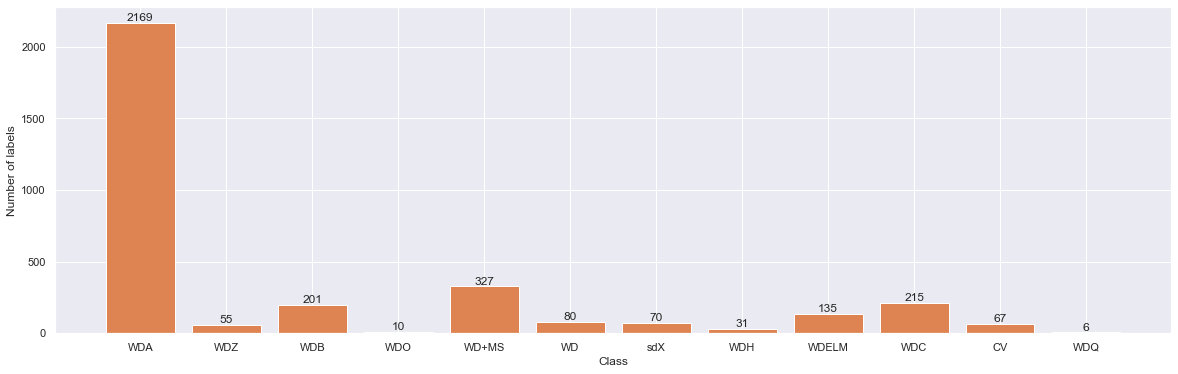

In [52]:
from collections import Counter

# Plot bar graph of labels

counter = Counter(train_set['classID'])
star_class = counter.keys()
star_counts = counter.values()
indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

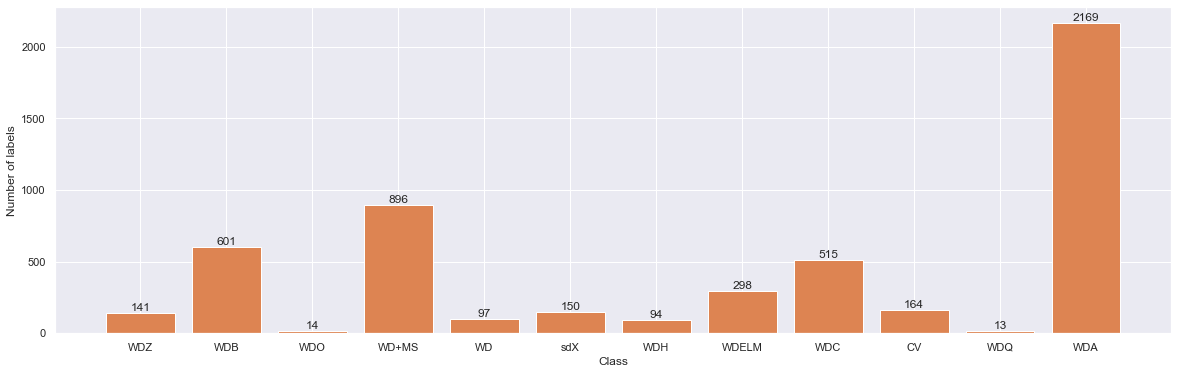

In [53]:
from collections import Counter

# Plot bar graph of labels

counter = Counter(da_train_set['classID'])
star_class = counter.keys()
star_counts = counter.values()
indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

## Build Features

In [54]:
import sys
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../src'))
import src.features.build_features as bfs

In [55]:
from sklearn.preprocessing import OneHotEncoder

sdss_data_path = os.path.join(project_dir, r'data\raw\sdss_dat_files')
# print(test_set.shape)
train_spectrum_matrix = bfs.data_processing_and_loading(sdss_data_path, da_train_set)
# print(train_set.shape)
valid_spectrum_matrix = bfs.data_processing_and_loading(sdss_data_path, da_valid_set)

# One hot encoding categorical data

ohe = OneHotEncoder(sparse=False)
train_ohe_labels = ohe.fit_transform(da_train_set[['classID']])
valid_ohe_labels = ohe.fit_transform(da_valid_set[['classID']])

In [56]:
save_folder = os.path.join(project_dir, r'data\processed')
np.save(os.path.join(save_folder, 'da_train_spectrum_matrix.npy'), train_spectrum_matrix)
np.save(os.path.join(save_folder,'da_valid_spectrum_matrix.npy'), valid_spectrum_matrix)
np.save(os.path.join(save_folder, 'da_train_label_matrix.npy'), train_ohe_labels)
np.save(os.path.join(save_folder,'da_valid_label_matrix.npy'), valid_ohe_labels)

## Train model

In [57]:
from imblearn.over_sampling import RandomOverSampler
import keras
from tensorflow import keras
from keras.layers import Dense
from keras.optimizers import SGD
from keras.layers import Conv1D
from keras.layers import MaxPooling1D
from keras.layers import Flatten

In [59]:
train_label_matrix = np.load(os.path.join(project_dir, r'data\processed\da_train_label_matrix.npy'))
valid_label_matrix = np.load(os.path.join(project_dir, r'data\processed\da_valid_label_matrix.npy'))

# Over sampling the imbalanced dataset

over_sampler = RandomOverSampler(random_state=40, sampling_strategy='not majority')
X_over, Y_over = over_sampler.fit_resample(train_spectrum_matrix, train_label_matrix)

In [60]:
unique, counts = np.unique(Y_over, return_counts=True, axis=0)

result = np.column_stack((unique, counts)) 
print (result)

[[   0    0    0    0    0    0    0    0    0    0    0    1 2169]
 [   0    0    0    0    0    0    0    0    0    0    1    0 2169]
 [   0    0    0    0    0    0    0    0    0    1    0    0 2169]
 [   0    0    0    0    0    0    0    0    1    0    0    0 2169]
 [   0    0    0    0    0    0    0    1    0    0    0    0 2169]
 [   0    0    0    0    0    0    1    0    0    0    0    0 2169]
 [   0    0    0    0    0    1    0    0    0    0    0    0 2169]
 [   0    0    0    0    1    0    0    0    0    0    0    0 2169]
 [   0    0    0    1    0    0    0    0    0    0    0    0 2169]
 [   0    0    1    0    0    0    0    0    0    0    0    0 2169]
 [   0    1    0    0    0    0    0    0    0    0    0    0 2169]
 [   1    0    0    0    0    0    0    0    0    0    0    0 2169]]


In [62]:
model = keras.Sequential([Conv1D(filters=128, kernel_size=4, activation='relu', strides=2, input_shape=(X_over.shape[1],1)),
                MaxPooling1D(pool_size=2),
                Conv1D(filters=64, kernel_size=4, activation='relu', strides=2),
                MaxPooling1D(pool_size=2),
                Conv1D(filters=32, kernel_size=4, activation='relu', strides=2),
                MaxPooling1D(pool_size=2),
                Conv1D(filters=16, kernel_size=4, activation='relu', strides=2),
                MaxPooling1D(pool_size=2),
                Flatten(),
                Dense(64, activation='relu', kernel_initializer='uniform'),
                Dense(32, activation='relu', kernel_initializer='uniform'),
                Dense(12, activation='softmax', kernel_initializer='uniform')])

opt = keras.optimizers.Adam(learning_rate=0.003)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
history = model.fit(X_over, Y_over, batch_size=128, epochs=20 , validation_data=(valid_spectrum_matrix, valid_label_matrix))

Epoch 1/20
204/204 [==============================] - 92s 449ms/step - loss: 1.4650 - accuracy: 0.4972 - val_loss: 1.1100 - val_accuracy: 0.7029
Epoch 2/20
204/204 [==============================] - 92s 453ms/step - loss: 0.6861 - accuracy: 0.7717 - val_loss: 0.7282 - val_accuracy: 0.8094
Epoch 3/20
204/204 [==============================] - 93s 453ms/step - loss: 0.4502 - accuracy: 0.8514 - val_loss: 0.7857 - val_accuracy: 0.7751
Epoch 4/20
204/204 [==============================] - 91s 445ms/step - loss: 0.3508 - accuracy: 0.8832 - val_loss: 1.3231 - val_accuracy: 0.7799
Epoch 5/20
204/204 [==============================] - 89s 434ms/step - loss: 0.2937 - accuracy: 0.9029 - val_loss: 0.7967 - val_accuracy: 0.7992
Epoch 6/20
204/204 [==============================] - 88s 430ms/step - loss: 0.2214 - accuracy: 0.9290 - val_loss: 0.9372 - val_accuracy: 0.8106
Epoch 7/20
204/204 [==============================] - 86s 424ms/step - loss: 0.1950 - accuracy: 0.9373 - val_loss: 0.9153 - val_ac

In [63]:
import pickle

model.save(os.path.join(project_dir, 'models\CNN_dav1'))
with open(os.path.join(project_dir, 'models\CNN_dav1_trainHistory'), 'wb') as file_pi:
    pickle.dump(history.history, file_pi)

INFO:tensorflow:Assets written to: c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\models\CNN_dav1\assets


INFO:tensorflow:Assets written to: c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\models\CNN_dav1\assets


## Visualizing Results

In [64]:
from sklearn.metrics import confusion_matrix

valid_sample_output = model.predict(valid_spectrum_matrix, batch_size=60)
predict_class = np.argmax(valid_sample_output, axis=1)
actual_class = np.argmax(valid_label_matrix, axis=1)
cf_matrix = confusion_matrix(actual_class, predict_class)

28/28 [==============================] - 2s 61ms/step


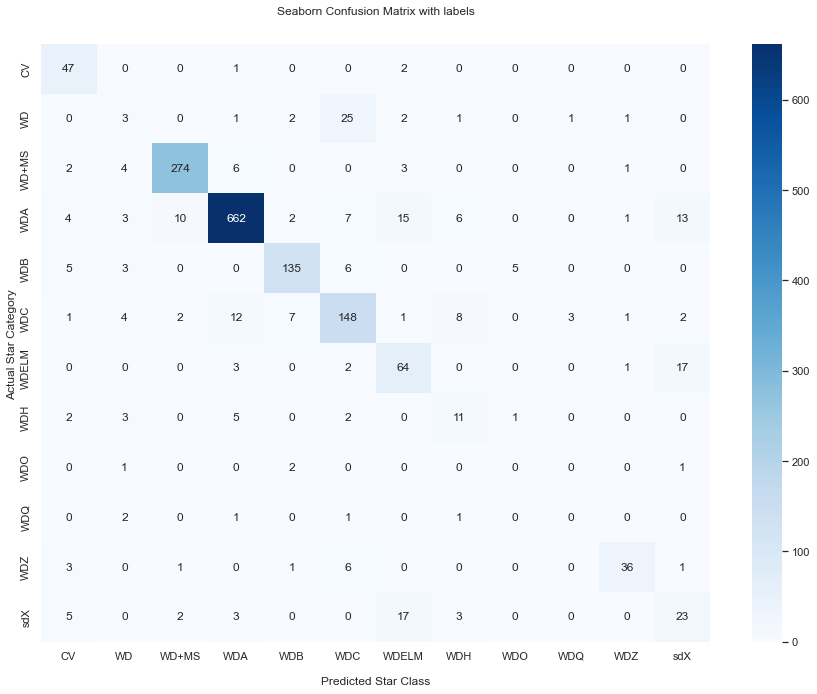

In [65]:
ohe_dict = vsz.ohe_decoder(da_train_set['classID'], train_label_matrix)
star_class = vsz.sort_ohe(ohe_dict)

sns.set(rc = {'figure.figsize':(15,11)})
ax = sns.heatmap(cf_matrix, annot=True, fmt='.3g', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Star Class')
ax.set_ylabel('Actual Star Category ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(star_class)
ax.yaxis.set_ticklabels(star_class)

## Display the visualization of the Confusion Matrix.
plt.show()

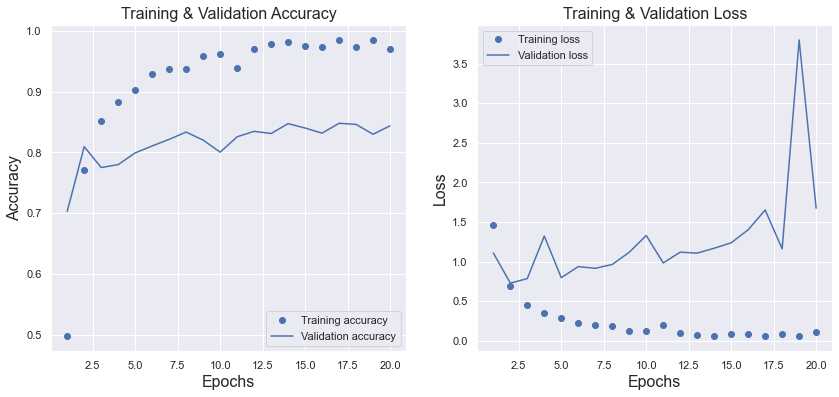

In [66]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']
 
epochs = range(1, len(loss_values) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
#
# Plot the model accuracy vs Epochs
#
ax[0].plot(epochs, accuracy, 'bo', label='Training accuracy')
ax[0].plot(epochs, val_accuracy, 'b', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()
#
# Plot the loss vs Epochs
#
ax[1].plot(epochs, loss_values, 'bo', label='Training loss')
ax[1].plot(epochs, val_loss_values, 'b', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()